<a href="https://colab.research.google.com/github/MahiDeshpande/when-metrics-disagree/blob/main/when_metrics_disagree_ILSVRC2012_val_00001403.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **When Metrics Disagree: A Visual Investigation of PSNR, SSIM, LPIPS, and TPIPS**

## **The main question?**
Our main question that we are trying to answer is: What does “image quality” actually mean, and when do PSNR, SSIM, LPIPS, and newer perceptual metrics (TPIPS) agree or disagree with what humans see?

This project explores three core layers:
1. **Understanding Metric Perceptions:** Analyzing how each algorithm interprets image variations.
2. **Controlled Stress-Testing:** Subjecting benchmark images to synthetic transformations (pixel shifts, Gaussian blurs, noise, JPEG compression, and brightness shifts).
3. **Counterexample Discovery:** Finding failure modes where metric score rankings directly contradict human visual intuition.
4. **Bonus:** Going a little more in-depth into different models (SSIM vs MS-SSIM). Researching differences and/or variation when using different backbones (testing out AlexNet vs VGG for LPIPS)
---

## **Progress Tracker**

| Task / Experiment | Test Description | Status |
| :--- | :--- | :---: |
| **Setup & Dependencies** | Import libraries and initialize metric models (`skimage`, `lpips`, `tpips`). | done |
| **Test 1: Spatial Translation** | Evaluate metric sensitivity on 1–5 pixel shifts. | [ ] |
| **Test 2: High-Frequency Blur** | Measure metric response across increasing Gaussian blur radii. | [ ] |
| **Test 3: Noise & Artifacts** | Stress-test with Additive Noise & JPEG compression artifacts. | [ ] |
| **Test 4: Photometric Shifts** | Evaluate uniform brightness and contrast alterations. | [ ] |
| **Counterexample Analysis** | Compile side-by-side failure mode plots showing metric disagreements. | [ ] |

---

## **Extras & Additional Notes**
- **Dataset:** Small image subset provided for benchmark testing.
- **Goal:** Export key visual plots and qualitative findings into the final technical blog post and project repository.

### **Definitions of the 4 metrics we will be comparing** ###

### 1. PSNR (Peak Signal-to-Noise Ratio)

**The Metaphor:** A strict, pixel-by-pixel accountant.
PSNR compares two images by subtracting the exact RGB values of every single pixel in Image A from Image B, squaring the differences, and taking the average (Mean Squared Error). It then converts that error into a logarithmic decibel scale.

* **How it works:** It measures pixel-level reconstruction error. If every pixel matches identically, error is zero, and PSNR is infinite ($\infty$). As pixels differ, PSNR drops.
* **Direction:** **Higher ($\uparrow$) is better.**
* **Typical Range:** $20\text{ dB}$ (heavily degraded) to $40+\text{ dB}$ (virtually identical).
* **The Major Blind Spot ("The Alignment Trap"):** Shift an image to the right by just **2 pixels**. To a human, the image looks completely unchanged. But to PSNR, every single pixel line is now misaligned, causing the score to plummet from $40\text{ dB}$ down to $15\text{ dB}$.

---

### 2. SSIM (Structural Similarity Index)

**The Metaphor:** A localized pattern checker.
Created to fix PSNR's flaws, SSIM doesn't just look at isolated pixels. Instead, it analyzes small local windows (e.g., $8\times 8$ pixel patches) and evaluates three specific features:

1. **Luminance:** Overall brightness of the patch.
2. **Contrast:** Spread of light and dark values within the patch.
3. **Structure:** The directional patterns, textures, and edges.

* **How it works:** It outputs a single normalized score comparing structural correlation between patches.
* **Direction:** **Higher ($\uparrow$) is better.**
* **Typical Range:** $-1.0$ to $1.0$ (where $1.0$ means identical structure).
* **The Major Blind Spot:** SSIM is still bound to spatial coordinates. While it handles mild luminance changes better than PSNR, moderate spatial translations or slight rotations still break the local window comparisons, causing artificial score drops.

---

### 3. LPIPS (Learned Perceptual Image Patch Similarity)

**The Metaphor:** A simulated human visual cortex (CNN feature extractor).
Instead of calculating mathematical distances between pixels, LPIPS passes both images through a pre-trained Convolutional Neural Network (like **AlexNet** or **VGG**).

* **How it works:**
1. The network extracts feature maps across different deep layers (from low-level edges in early layers to high-level shapes in deeper layers).
2. It computes the distance between those deep feature activations.
3. It weights those differences based on human perceptual judgement datasets.


* **Direction:** **Lower ($\downarrow$) is better.**
* **Typical Range:** $0.00$ (perceptually identical) to $\approx 0.70+$ (completely different scene/texture).
* **Why it's better:** If you shift an image by 2 pixels or add mild texture noise, the deep feature activations in AlexNet/VGG remain almost identical. LPIPS correctly reflects that the image still "looks" fine to human eyes.

---

### 4. TPIPS (Text-Prompted Image Perceptual Similarity)

**The Metaphor:** An AI visual-language critic (VLM reasoning model).
TPIPS is the newest metric on the block. Instead of relying on traditional CNNs, it routes images through a massive Vision-Language Model (specifically built on top of backbones like **Qwen3-VL-8B**).

* **How it works:**
1. Images are patchified into multimodal embeddings that link visual concepts directly to text.
2. You can pass a **text prompt condition** (like `factor="overall"`, `factor="lighting"`, or `factor="color"`).
3. The text prompt acts as an attention steering vector, forcing the network to evaluate perceptual similarity *specifically along that visual dimension*.


* **Direction:** **Lower ($\downarrow$) is better.**
* **Typical Range:** $0.00$ (identical semantic alignment) to $2.0$ (maximum vector distance).
* **Why it's revolutionary:** It understands high-level semantic context. If an image is dark but the object structure, geometry, and key semantic features remain intact, TPIPS evaluates the image with broad context rather than getting tripped up by raw pixel variance.

---

### Metric Comparison Cheatsheet

| Metric | Category | Primary Focus | Unit / Scale | Sensitivity to 2-Pixel Shift |
| --- | --- | --- | --- | --- |
| **PSNR** | Classical Math | Pixel-level RGB error | Decibels ($\text{dB}$) $[0, \infty)$ | **Extreme penalty** (Plummets) |
| **SSIM** | Classical Pattern | Local luminance, contrast, edges | Index $[-1.0, 1.0]$ | **Moderate penalty** |
| **LPIPS** | Deep Features (CNN) | Mid-to-high level feature maps | Distance $[0.0, \approx 1.0]$ | **Invariant** (Stays flat) |
| **TPIPS** | Vision-Language (VLM) | High-level scene & aspect semantics | Distance $[0.0, 2.0]$ | **Invariant** (Stays flat) |

**Disclaimer:** The score ranges provided represent generalized, typical trends observed across standard image quality literature and benchmarks. Actual metric responses can fluctuate based on the specific dataset, the nature of the distortions, and the underlying network architecture (e.g., AlexNet vs. VGG).

**Table Description:** This reference matrix translates raw, numerical image quality scores into intuitive visual fidelity descriptors. It maps the traditional pixel-wise math of PSNR and local structure analysis of SSIM alongside the learned human-perception approximations of LPIPS and the vision-language context of TPIPS. This provides a quick heuristic for assessing the severity of image degradation across both classical and neural evaluation frameworks.

**Sources:**

1. *PSNR, SSIM, and LPIPS Explained Simply*, Medium (2026)
2. *Making Sense of PSNR, SSIM, VMAF*, Visionular (2024)
3. *TPIPS: The Many Senses of Visual Similarity*, Sheng-Yu Wang et al., Adobe Research (2026)

### Metric Interpretation Guide

| Intent Match | Visual Quality Descriptor | PSNR (dB) ↑ | SSIM ↑ | LPIPS-Alex ↓ | LPIPS-VGG ↓ | TPIPS ↓ |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **90-100%** | **Indistinguishable / Flawless** | > 40 | 0.95 - 1.00 | 0.00 - 0.05 | 0.00 - 0.08 | 0.00 - 0.03 |
| **70-90%** | **Slight Degradation / Excellent** | 32 - 40 | 0.85 - 0.95 | 0.05 - 0.15 | 0.08 - 0.20 | 0.03 - 0.08 |
| **50-70%** | **Noticeable Distortion / Acceptable** | 25 - 32 | 0.70 - 0.85 | 0.15 - 0.30 | 0.20 - 0.35 | 0.08 - 0.15 |
| **30-50%** | **Obvious Distortion / Poor** | 20 - 25 | 0.50 - 0.70 | 0.30 - 0.50 | 0.35 - 0.55 | 0.15 - 0.25 |
| **10-30%** | **Heavy Degradation / Very Poor** | 15 - 20 | 0.25 - 0.50 | 0.50 - 0.70 | 0.55 - 0.75 | 0.25 - 0.35 |
| **0-10%** | **Unrecognizable / Destroyed** | < 15 | < 0.25 | > 0.70 | > 0.75 | > 0.35 |

*Note: TPIPS operates on a highly compressed semantic scale compared to classical LPIPS. A TPIPS distance of 0.35 indicates catastrophic damage, whereas LPIPS requires a score closer to 0.75 to reflect that same level of visual destruction.*

*(Note: TPIPS ranges are approximations based on typical Vision-Language Model distance distributions, which tend to cluster lower than raw LPIPS scores for similar distortions).*

## **Installing Required Libraries To Run Image Quality Metrics**

OpenCV, scikit-image, PyTorch, LPIPS, Matplotlib, and HuggingFace Transfomers (for TPIPS backbones)

---

In [2]:
# -------------------------------------------------------------------------
# FAST PREMIUM GPU SETUP SCRIPT (L4 / A100)
# -------------------------------------------------------------------------
# 👉 Added this line back to satisfy the strict version requirement
!pip install -q --upgrade torchao

!pip install -q opencv-python-headless scikit-image torch torchvision lpips matplotlib ftfy regex tqdm transformers accelerate
!pip install -q git+https://github.com/adobe-research/TPIPS.git

import gc
import os
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import lpips
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import tpips

# ==========================================
# 1. WIPE GHOST MEMORY
# ==========================================
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. LOAD LPIPS TO GPU
# ==========================================
print("Loading LPIPS to GPU...")
lpips_alex = lpips.LPIPS(net="alex").to(device).eval()
lpips_vgg = lpips.LPIPS(net="vgg").to(device).eval()

# ==========================================
# 3. LOAD TPIPS DIRECTLY TO PREMIUM GPU
# ==========================================
print("Loading TPIPS directly to the L4/A100 GPU...")

# Use float16 for speed and memory efficiency
torch.set_default_dtype(torch.float16)

# The L4 has 24GB of VRAM, so we skip the CPU and load directly to CUDA
tpips_model = tpips.load_model("embedding", device="cuda")

# Restore standard PyTorch settings for evaluation metrics
torch.set_default_dtype(torch.float32)
tpips_model.eval()

print("\n✅ WE MADE IT! Model is locked and loaded on the premium GPU.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 104.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Loading LPIPS to GPU...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/vgg.pth
Loading TPIPS directly to the L4/A100 GPU...
[load_model] fetching sywang/TPIPS-Embed-Qwen3VL-8B from Hugging Face ...


...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/749 [00:00<?, ?it/s]

[embedding] LoRA on LLM (r=16, alpha=32); 38.9M trainable / 8183.7M total


[transformers] The tokenizer you are loading from '/root/.cache/huggingface/hub/models--sywang--TPIPS-Embed-Qwen3VL-8B/snapshots/86a1493c60121e656a1c075bc7aed88f25fcd4d4' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


[load_model] embedding loaded from /root/.cache/huggingface/hub/models--sywang--TPIPS-Embed-Qwen3VL-8B/snapshots/86a1493c60121e656a1c075bc7aed88f25fcd4d4 on cuda

✅ WE MADE IT! Model is locked and loaded on the premium GPU.



### The Main Functions Used to Carry Out the 4 Metrics and Visualise Them

This block defines our central helper functions (`compute_all_metrics` and `plot_sweep_grid`) that power every test case in this notebook.

To make these 4 fundamentally different metric families **directly comparable**, our pipeline forces every model to evaluate the exact same image pair simultaneously under strict resolution, color space, and memory alignment standards.

**How We Ensure Rigorous Cross-Metric Comparability:**

1. **Input Normalization Standard:** Every input image pair ($I_{\text{ref}}, I_{\text{dist}}$) is passed as a $512 \times 512 \times 3$ NumPy array scaled strictly to $[0.0, 1.0]$. This eliminates resolution bias across model backbones.
2. **Parallel Input Formatting:**
* **Classical Math Metrics (PSNR, SSIM):** Evaluated directly on the raw $[0.0, 1.0]$ float arrays across all 3 color channels ($H \times W \times C$).
* **Deep Feature Models (LPIPS Alex & VGG):** Transformed into 4D PyTorch tensors ($1 \times C \times H \times W$), rescaled to $[-1.0, 1.0]$, and loaded directly onto the GPU (`device`).
* **Multimodal Vision-Language Model (TPIPS):** Converted back into 8-bit PIL images ($0\text{--}255$), maintaining spatial resolution while executing through its deep vision-language embedding space.


3. **Execution & Direction Alignment:** Every metric runs inside inference mode (`torch.no_grad()` / `torch.inference_mode()`) to freeze network weights and prevent gradient accumulation. Scores are recorded alongside directional arrows—**Higher ($\uparrow$)** for quality/similarity, **Lower ($\downarrow$)** for perceptual distance—allowing us to track score trajectory convergence and divergence across experiments.


In [3]:
# =========================================================================
# CELL 2: CORE EVALUATION & VISUALIZATION HELPERS (BFLOAT16 FIX)
# =========================================================================

def compute_all_metrics(img_ref_np, img_dist_np, factor="overall"):
    """Computes PSNR, SSIM, LPIPS (Alex & VGG), and TPIPS for an image pair."""
    # 1. PSNR & SSIM (Classical Metrics)
    score_psnr = compute_psnr(img_ref_np, img_dist_np, data_range=1.0)
    score_ssim = compute_ssim(
        img_ref_np, img_dist_np, channel_axis=2, data_range=1.0
    )

    # 2. Prepare Tensors for LPIPS (Forcing standard float32)
    tensor_ref = (
        torch.tensor(img_ref_np).permute(2, 0, 1).unsqueeze(0).float().to(device)
        * 2
        - 1
    )
    tensor_dist = (
        torch.tensor(img_dist_np).permute(2, 0, 1).unsqueeze(0).float().to(device)
        * 2
        - 1
    )

    with torch.no_grad():
        # Ensure LPIPS models run in float32 to avoid precision crashes
        lpips_alex.to(torch.float32)
        lpips_vgg.to(torch.float32)
        score_lpips_alex = lpips_alex(tensor_ref, tensor_dist).item()
        score_lpips_vgg = lpips_vgg(tensor_ref, tensor_dist).item()

    # 3. Prepare PIL Images for TPIPS
    img_ref_pil = Image.fromarray((img_ref_np * 255).astype(np.uint8))
    img_dist_pil = Image.fromarray((img_dist_np * 255).astype(np.uint8))

    # FIX: Use autocast to bridge 32-bit PIL processing with our 16-bit quantized model
    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        score_tpips = tpips_model.distance(
            img_ref_pil, img_dist_pil, factor=factor
        )
        if isinstance(score_tpips, torch.Tensor):
            score_tpips = score_tpips.item()

    return {
        "PSNR (↑)": round(score_psnr, 2),
        "SSIM (↑)": round(score_ssim, 4),
        "LPIPS-Alex (↓)": round(score_lpips_alex, 4),
        "LPIPS-VGG (↓)": round(score_lpips_vgg, 4),
        "TPIPS Distance (↓)": round(score_tpips, 4),
    }

def plot_sweep_grid(
    img_ref, distortion_fn, levels, param_name="Level", exp_title="Sweep"
):
    """Generates a 2-row layout followed by a metric summary table."""
    num_levels = len(levels)
    fig, axes = plt.subplots(
        2, num_levels, figsize=(3.5 * num_levels, 6), squeeze=False
    )

    results = []

    for i, lvl in enumerate(levels):
        img_dist = distortion_fn(img_ref, lvl)

        axes[0, i].imshow(img_ref)
        axes[0, i].set_title("Original Ref", fontsize=10)
        axes[0, i].axis("off")

        axes[1, i].imshow(img_dist)
        axes[1, i].set_title(f"{param_name}: {lvl}", fontsize=10)
        axes[1, i].axis("off")

        scores = compute_all_metrics(img_ref, img_dist)
        scores[param_name] = lvl
        results.append(scores)

    plt.suptitle(f"Distortion Grid: {exp_title}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    df_results = pd.DataFrame(results)
    cols = [param_name] + [c for c in df_results.columns if c != param_name]
    display(df_results[cols])

    return df_results

print("✅ Updated Helper Functions Loaded (with BFloat16 Autocast Fix)!")

✅ Updated Helper Functions Loaded (with BFloat16 Autocast Fix)!


### Phase 1: Experiment 1 — The Basic Distortion Zoo

This phase establishes **Experiment 1**, the foundational stress-testing suite in our comparative Image Quality Assessment (IQA) research framework. The primary objective is to systematically isolate and measure how classical mathematical metrics (**PSNR, SSIM**), deep feature extractors (**LPIPS-Alex, LPIPS-VGG**), and multimodal vision-language models (**TPIPS** running on Qwen3-VL-8B) behave under synthetic, controlled image degradations.

Experiment 1 serves as the entry point to a multi-stage experimental roadmap (comprising higher-order evaluations like Iso-PSNR Calibration, Heatmap Clustering, Rank Disagreement Mining, and Human Perception Alignment).

---

#### 1. Experimental Breakdown (10 Isolated Tests)

Experiment 1 is partitioned into **10 distinct parametric test cells**. Each test isolates a single geometric, noise, or photometric transformation across 4 progressive severity levels:

| Test # | Distortion Category | Parameter Sweep Levels | Primary Geometric / Perceptual Target |
| :--- | :--- | :--- | :--- |
| **Test 1** | **(Clipped) Gaussian Noise** | $\sigma = 5, 10, 20, 40$ | High-frequency additive noise & boundary clipping effects |
| **Test 2** | **Gaussian Blur** | Radius $= 1, 2, 4, 8\text{ px}$ | High-frequency loss & smooth detail suppression |
| **Test 3** | **JPEG Compression** | Quality $= 90, 70, 40, 10$ | Blocky $8\times8$ frequency artifacts & ringing |
| **Test 4** | **Brightness Shift** | Scaling $= 0.7, 0.9, 1.1, 1.3$ | Global intensity shifts ($\pm 10\%, \pm 30\%$) |
| **Test 5** | **Contrast Alteration** | Scaling $= \times 0.7, \times 1.3$ | Dynamic range expansion and compression |
| **Test 6** | **Saturation Alteration** | Scaling $= \times 0.0, \times 0.5, \times 1.5$ | Color fidelity (Monochrome to over-saturated) |
| **Test 7** | **Spatial Translation** | Shift $= 1, 2, 4, 8\text{ pixels}$ | Spatial alignment sensitivity ("The Alignment Trap") |
| **Test 8** | **Spatial Rotation** | Angle $= 1^\circ, 3^\circ, 5^\circ, 10^\circ$ | Rotational invariance & resampling artifacts |
| **Test 9** | **Crop + Resize** | Crop $= 2\%, 5\%, 10\%, 20\%$ | Field-of-view alteration & interpolation scaling |
| **Test 10** | **Color Shift (Hue)** | Offset $= 10^\circ, 30^\circ, 60^\circ, 90^\circ$ | HSV channel phase rotation |

---

#### 2. Visual & Analytical Output Format

To maintain complete visual clarity and consistency across all 10 notebook cells, every test executes via our unified helper pipeline (`plot_sweep_grid`) and renders a three-part output display:

* **Top Row (Original Baseline):** Displays 4 identical side-by-side tiles of the pristine reference image ($512\times512$), providing a direct local comparison for each step.
* **Bottom Row (Distorted Grid):** Displays the corresponding distorted image right underneath its reference tile, visually highlighting how artifacts progress from mild to extreme.
* **Metric Trajectory Data Table:** Renders a Pandas DataFrame displaying the calculated numerical scores across all 5 metrics (**PSNR, SSIM, LPIPS-Alex, LPIPS-VGG, TPIPS**) alongside the distortion level.

---

#### 3. Execution Pipeline & Standardized Setup

1. **Resolution Normalization:** Input images are standardized to $512\times512$ float arrays ($[0.0, 1.0]$ range). This optimizes CPU execution speed for the 8B-parameter TPIPS backbone without sacrificing perceptual fidelity.
2. **Deterministic Evaluation:** Each code cell operates independently. Running a cell automatically applies the specific transformation function, visualizes the 2-row image matrix, computes all metric tensors, and outputs the formatted summary table.

In [155]:
# ==========================================
# CELL 3: DATASET LOADER (WITH DEBUG PRINTS)
# ==========================================
from google.colab import drive
import os
import cv2
from PIL import Image
import numpy as np

print("Step 1: Checking Google Drive connection...")
try:
    drive.mount('/content/drive')
    print("✅ Drive is mounted.")
except Exception as e:
    print(f"❌ Drive mount failed: {e}")

# 👉 YOUR EXACT GOOGLE DRIVE FOLDER PATH
DATASET_PATH = "/content/drive/MyDrive/research"

print(f"\nStep 2: Looking for folder -> {DATASET_PATH}")
if not os.path.exists(DATASET_PATH):
    print("❌ FAILED: The folder path does not exist. Double-check the path above.")
else:
    print("✅ Folder found!")

    print("\nStep 3: Scanning folder for image files...")
    valid_exts = ('.png', '.jpg', '.jpeg')
    image_files = sorted([f for f in os.listdir(DATASET_PATH) if f.lower().endswith(valid_exts)])

    print(f"✅ Found {len(image_files)} valid images.")

    if len(image_files) == 0:
        print("❌ FAILED: The folder is empty or contains no valid images.")
    else:
        # Change this index to load a different image (0 to 49)
        INDEX = 8
        img_name = image_files[INDEX]
        img_path = os.path.join(DATASET_PATH, img_name)

        print(f"\nStep 4: Attempting to read image [Index {INDEX}] -> {img_name}")
        try:
            # Load with PIL first to guarantee it's a valid image file
            pil_img = Image.open(img_path).convert("RGB")
            pil_img = pil_img.resize((512, 512))
            print(f"✅ Image read successfully! Pixel Size: {pil_img.size}")

            print("\nStep 5: Formatting for the metric pipeline...")
            # Convert to float32 NumPy array scaled between 0.0 and 1.0
            img_ref_np = np.array(pil_img).astype(np.float32) / 255.0

            # Create the exact variable the test cells are looking for
            img_ref = img_ref_np

            print(f"✅ Formatting complete! Shape: {img_ref.shape}, Type: {img_ref.dtype}")
            print("\n🎉 SUCCESS! 'img_ref' is officially loaded into memory. You can now run the Test cells.")

        except Exception as e:
            print(f"❌ FAILED during image processing: {e}")

Step 1: Checking Google Drive connection...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive is mounted.

Step 2: Looking for folder -> /content/drive/MyDrive/research
✅ Folder found!

Step 3: Scanning folder for image files...
✅ Found 50 valid images.

Step 4: Attempting to read image [Index 8] -> Copy of ILSVRC2012_val_00001403.JPEG
✅ Image read successfully! Pixel Size: (512, 512)

Step 5: Formatting for the metric pipeline...
✅ Formatting complete! Shape: (512, 512, 3), Type: float32

🎉 SUCCESS! 'img_ref' is officially loaded into memory. You can now run the Test cells.


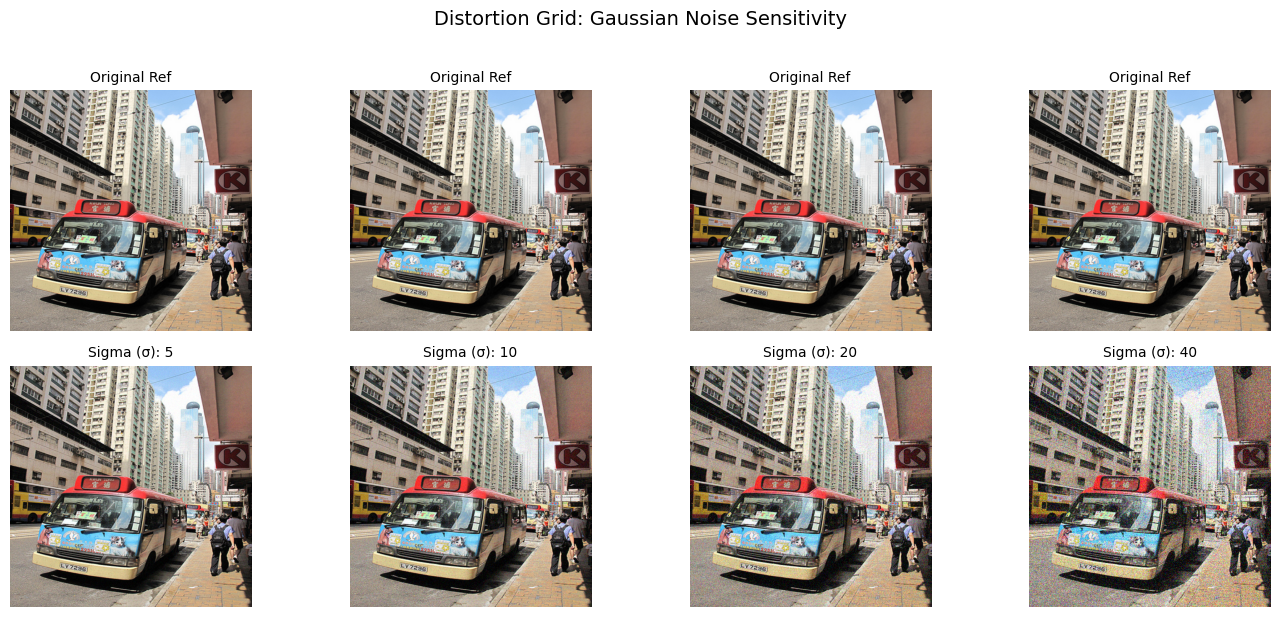

,Sigma (σ),PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,5,34.29,0.9325,0.0121,0.0626,0.0144
1,10,28.36,0.8198,0.0488,0.1484,0.0416
2,20,22.50,0.6418,0.1648,0.2896,0.0783
3,40,16.80,0.4318,0.4429,0.4958,0.1255


In [156]:
# =========================================================================
# TEST 1: (Clipped) Gaussian Noise Grid Sweep
# =========================================================================
# Define Noise Generator
def apply_gaussian_noise(img_np, sigma=10):
    """Adds zero-mean Gaussian noise scaled to float image range [0.0, 1.0]."""
    noise = np.random.normal(0, sigma / 255.0, img_np.shape)
    return np.clip(img_np + noise, 0.0, 1.0)


# Run 2x4 visual grid sweep + metric summary table
df_noise = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_gaussian_noise,
    levels=[5, 10, 20, 40],
    param_name="Sigma (σ)",
    exp_title="Gaussian Noise Sensitivity",
)

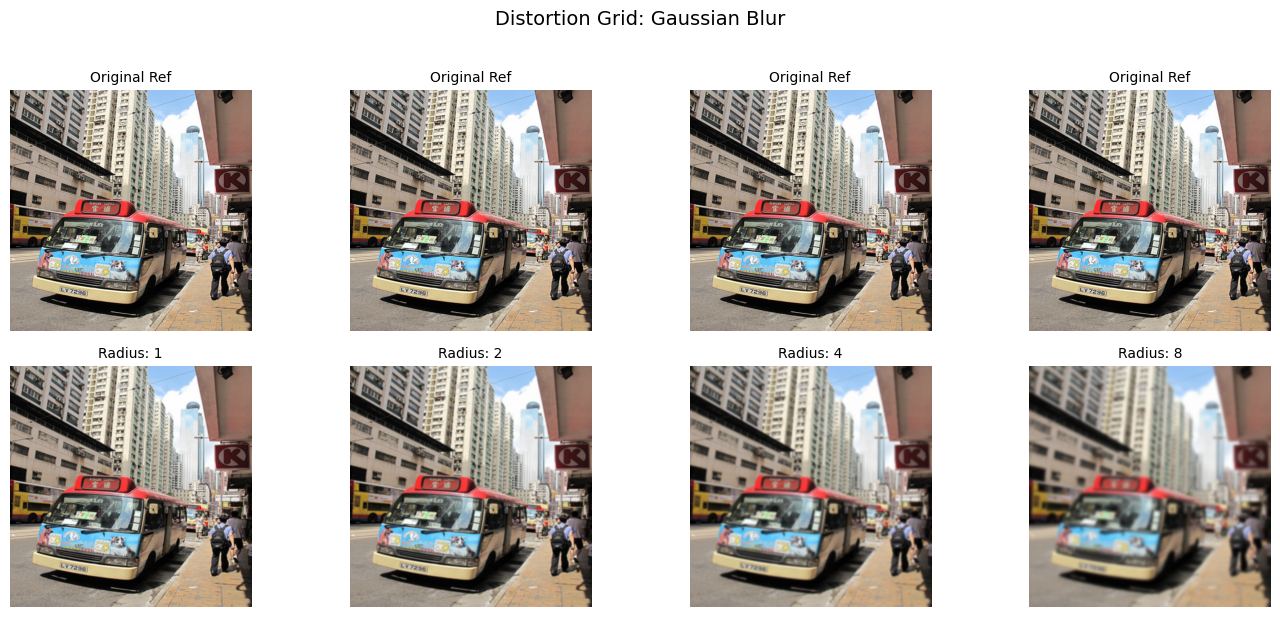

,Radius,PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,1,26.21,0.8979,0.1821,0.1031,0.0599
1,2,23.58,0.8111,0.3099,0.1841,0.0767
2,4,20.77,0.6482,0.4824,0.3298,0.1458
3,8,18.70,0.4776,0.6644,0.4988,0.2227


In [157]:
# =========================================================================
# TEST 2: Gaussian Blur Grid Sweep
# =========================================================================


def apply_gaussian_blur(img_np, radius=1):
    """Applies Gaussian Blur with odd kernel size derived from radius."""
    if radius <= 0:
        return img_np.copy()
    ksize = radius * 2 + 1
    return cv2.GaussianBlur(img_np, (ksize, ksize), 0)


# Run 2x4 visual grid + metric summary table
df_blur = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_gaussian_blur,
    levels=[1, 2, 4, 8],
    param_name="Radius",
    exp_title="Gaussian Blur",
)

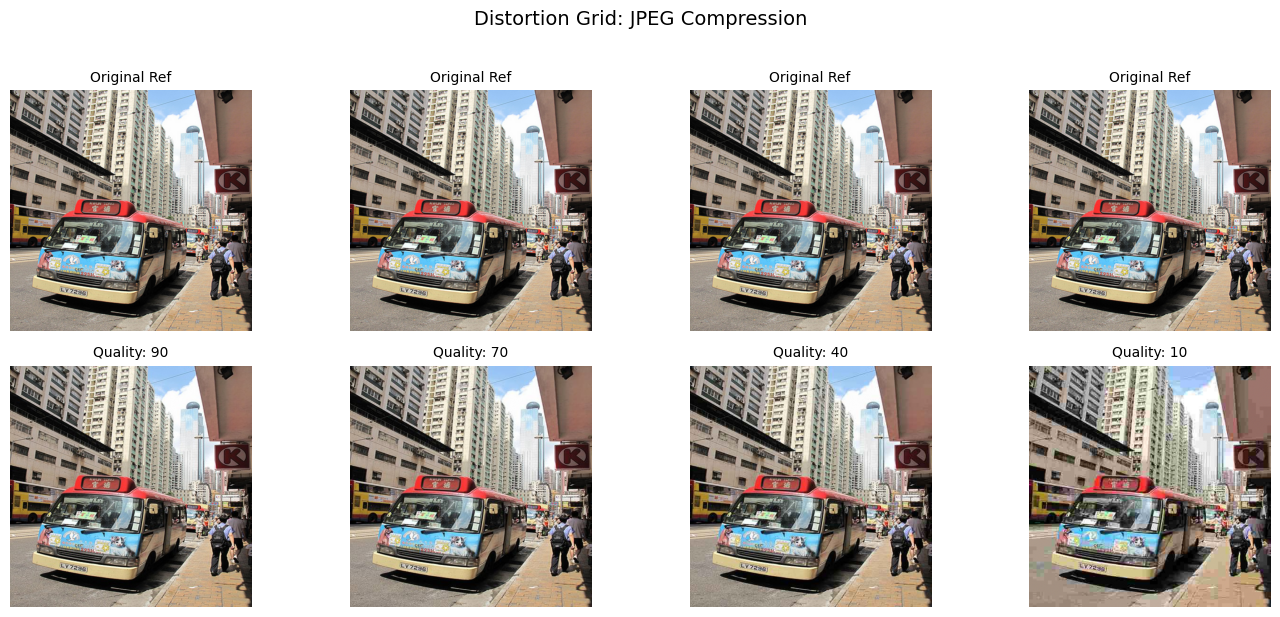

,Quality,PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,90,33.01,0.9621,0.0094,0.0465,0.0299
1,70,29.72,0.9252,0.0268,0.1071,0.0510
2,40,27.43,0.8841,0.0611,0.1674,0.0572
3,10,23.34,0.7574,0.2026,0.3558,0.0961


In [158]:
# =========================================================================
# TEST 3: JPEG Compression Grid Sweep
# =========================================================================

import io


def apply_jpeg_compression(img_np, quality=50):
    """Simulates JPEG compression artifacts in RAM."""
    img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
    buffer = io.BytesIO()
    img_pil.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    img_compressed = Image.open(buffer)
    return np.array(img_compressed) / 255.0


# Run 2x4 visual grid + metric summary table
df_jpeg = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_jpeg_compression,
    levels=[90, 70, 40, 10],
    param_name="Quality",
    exp_title="JPEG Compression",
)

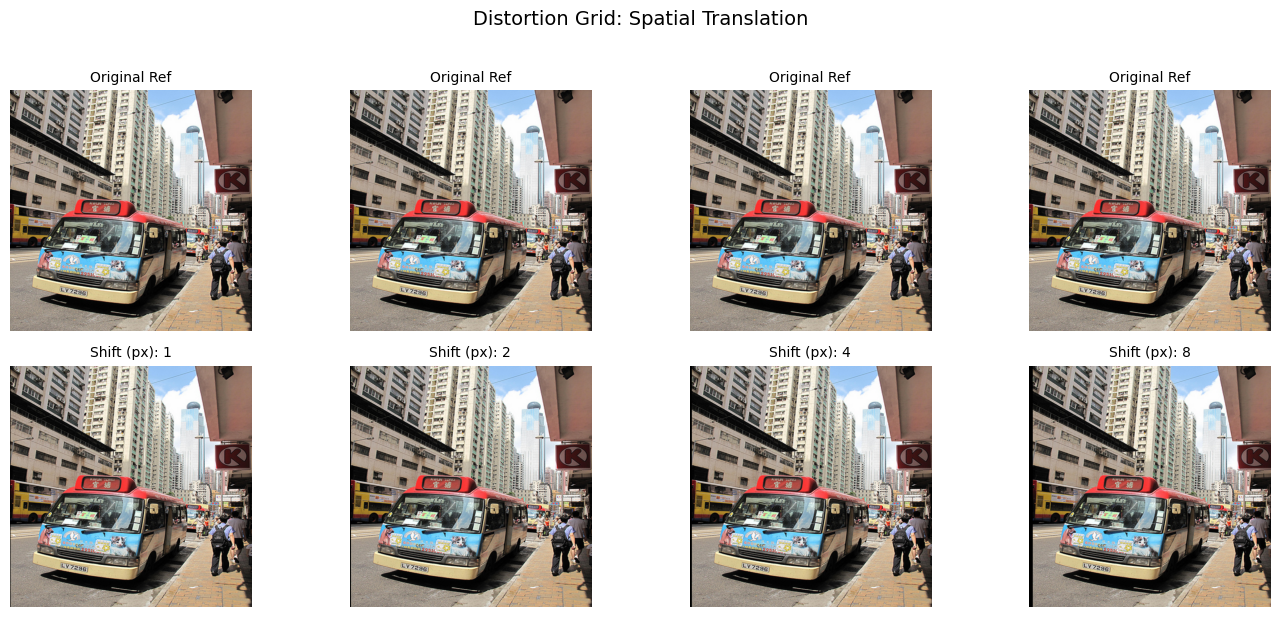

,Shift (px),PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,1,20.66,0.7583,0.0542,0.0739,0.0263
1,2,16.67,0.4682,0.0891,0.1460,0.0333
2,4,14.52,0.3258,0.1066,0.2312,0.0374
3,8,12.54,0.2078,0.1676,0.3406,0.0454


In [159]:
# =========================================================================
# TEST 4: Spatial Translation Grid Sweep
# =========================================================================


def apply_translation(img_np, shift_pixels=2):
    """Translates image horizontally with zero-padding at boundary."""
    rows, cols, _ = img_np.shape
    M = np.float32([[1, 0, shift_pixels], [0, 1, 0]])
    return cv2.warpAffine(img_np, M, (cols, rows))


# Run 2x4 visual grid + metric summary table
df_shift = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_translation,
    levels=[1, 2, 4, 8],
    param_name="Shift (px)",
    exp_title="Spatial Translation",
)

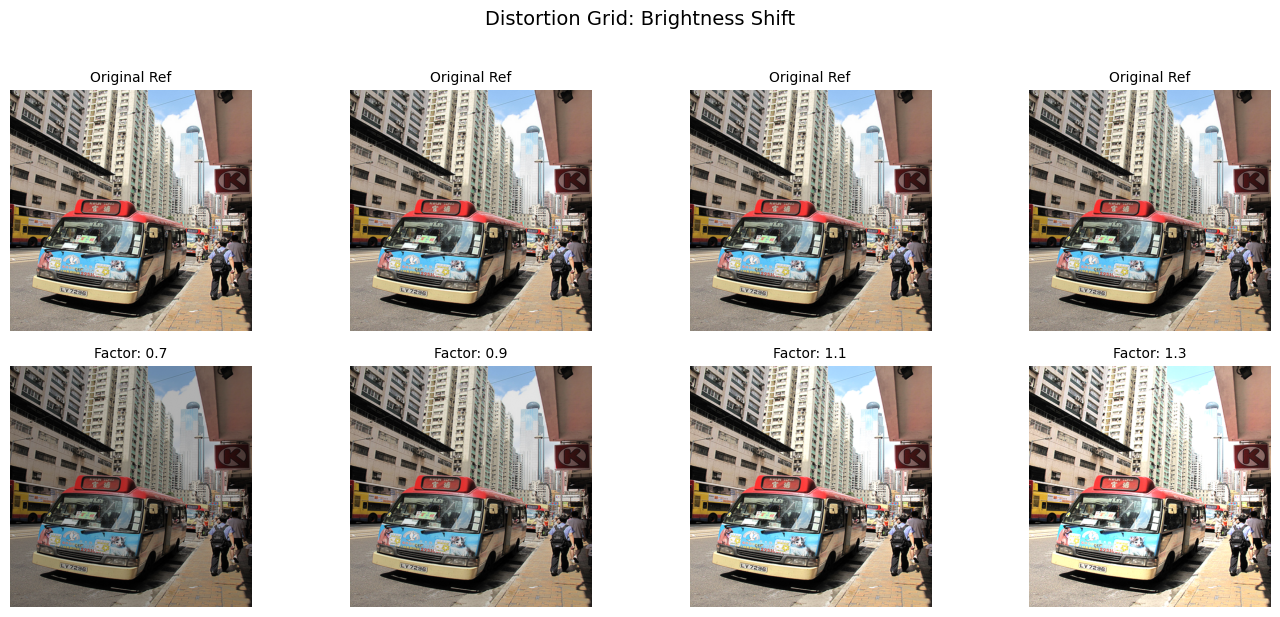

,Factor,PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,0.7,15.04,0.8927,0.0441,0.0344,0.0240
1,0.9,24.43,0.9888,0.0054,0.0061,0.0057
2,1.1,25.72,0.9861,0.0093,0.0130,0.0112
3,1.3,16.95,0.9117,0.0639,0.0710,0.0316


In [160]:
# =========================================================================
# TEST 5: Brightness Shift Grid Sweep
# =========================================================================

from PIL import ImageEnhance


def apply_brightness(img_np, factor=1.2):
    """Scales image brightness."""
    img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
    enhancer = ImageEnhance.Brightness(img_pil)
    return np.array(enhancer.enhance(factor)) / 255.0


# Run 2x4 visual grid + metric summary table
df_bright = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_brightness,
    levels=[0.7, 0.9, 1.1, 1.3],
    param_name="Factor",
    exp_title="Brightness Shift",
)

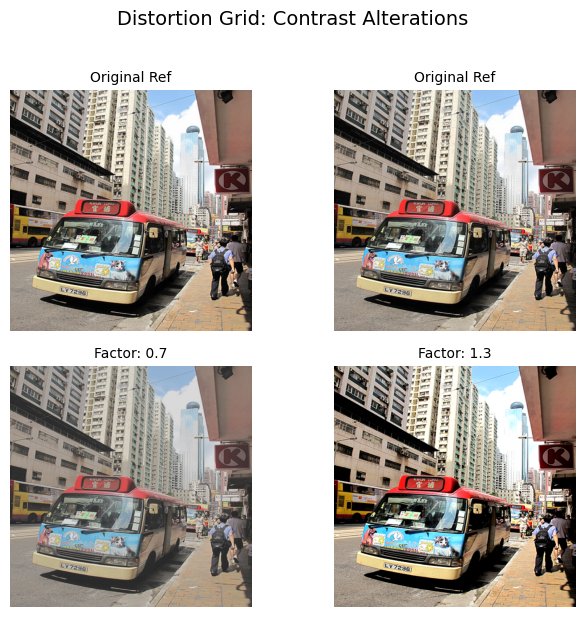

,Factor,PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,0.7,21.61,0.9020,0.0345,0.0372,0.0188
1,1.3,24.56,0.8886,0.0283,0.0560,0.0250


In [161]:
# =========================================================================
# TEST 6: Contrast Alterations
# =========================================================================


def apply_contrast(img_np, factor=1.0):
    """Scales image contrast."""
    img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
    return np.array(ImageEnhance.Contrast(img_pil).enhance(factor)) / 255.0


# Run 2x2 visual grid + metric summary table
df_contrast = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_contrast,
    levels=[0.7, 1.3],
    param_name="Factor",
    exp_title="Contrast Alterations",
)

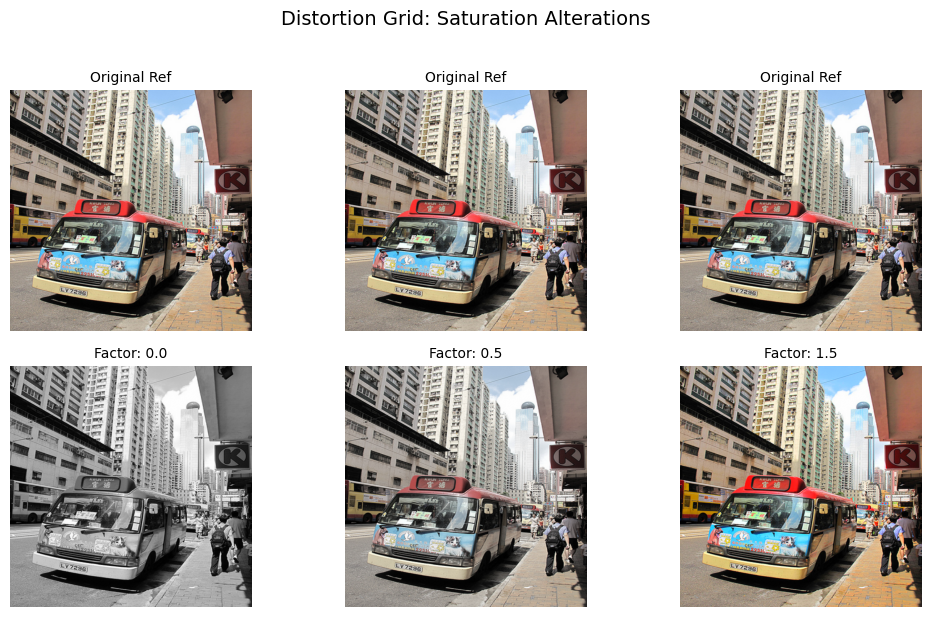

,Factor,PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,0.0,22.60,0.9497,0.1745,0.1331,0.2941
1,0.5,28.63,0.9850,0.0469,0.0297,0.0440
2,1.5,29.57,0.9846,0.0236,0.0165,0.0172


In [162]:
# =========================================================================
# TEST 7: Saturation Alterations
# =========================================================================


def apply_saturation(img_np, factor=1.0):
    """Scales image saturation (color intensity)."""
    img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
    return np.array(ImageEnhance.Color(img_pil).enhance(factor)) / 255.0


# Run 2x3 visual grid + metric summary table
df_saturation = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_saturation,
    levels=[0.0, 0.5, 1.5],
    param_name="Factor",
    exp_title="Saturation Alterations",
)

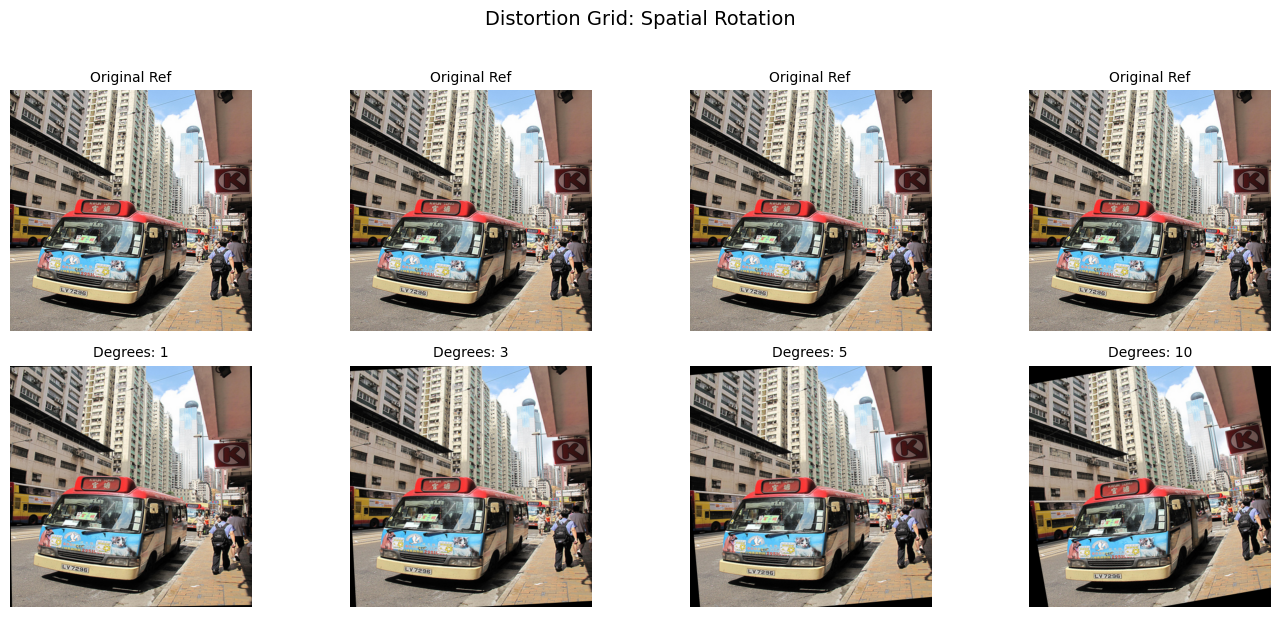

,Degrees,PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,1,14.81,0.3441,0.1455,0.2452,0.0362
1,3,11.72,0.1776,0.2734,0.4150,0.0563
2,5,10.52,0.1331,0.3777,0.4907,0.0677
3,10,9.47,0.1132,0.5173,0.5758,0.0976


In [163]:
# =========================================================================
# TEST 8: Spatial Rotation
# =========================================================================


def apply_rotation(img_np, degrees=0):
    """Rotates image around center with black boundary padding."""
    rows, cols, _ = img_np.shape
    M = cv2.getRotationMatrix2D((cols / 2, rows / 2), degrees, 1.0)
    return cv2.warpAffine(img_np, M, (cols, rows))


# Run 2x4 visual grid + metric summary table
df_rotation = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_rotation,
    levels=[1, 3, 5, 10],
    param_name="Degrees",
    exp_title="Spatial Rotation",
)

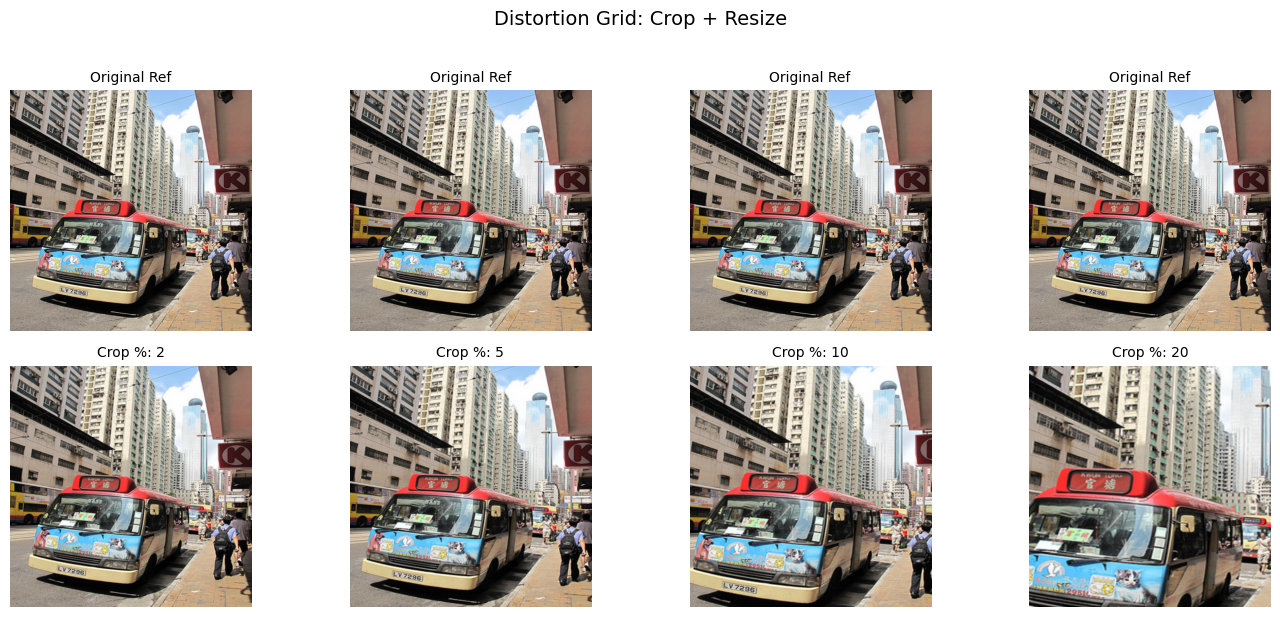

,Crop %,PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,2,13.09,0.2418,0.1981,0.3368,0.0549
1,5,10.67,0.1425,0.3918,0.4798,0.0618
2,10,9.55,0.0996,0.5444,0.5804,0.0814
3,20,8.66,0.0819,0.6724,0.6528,0.1714


In [164]:
# =========================================================================
# TEST 9: Crop + Resize
# =========================================================================


def apply_crop_resize(img_np, crop_percent=0):
    """Crops center region by percentage and resizes back to original size."""
    if crop_percent <= 0:
        return img_np.copy()
    h, w, _ = img_np.shape
    ch, cw = int(h * (crop_percent / 100.0)), int(w * (crop_percent / 100.0))
    cropped = img_np[ch : h - ch, cw : w - cw]
    return cv2.resize(cropped, (w, h))


# Run 2x4 visual grid + metric summary table
df_crop = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_crop_resize,
    levels=[2, 5, 10, 20],
    param_name="Crop %",
    exp_title="Crop + Resize",
)

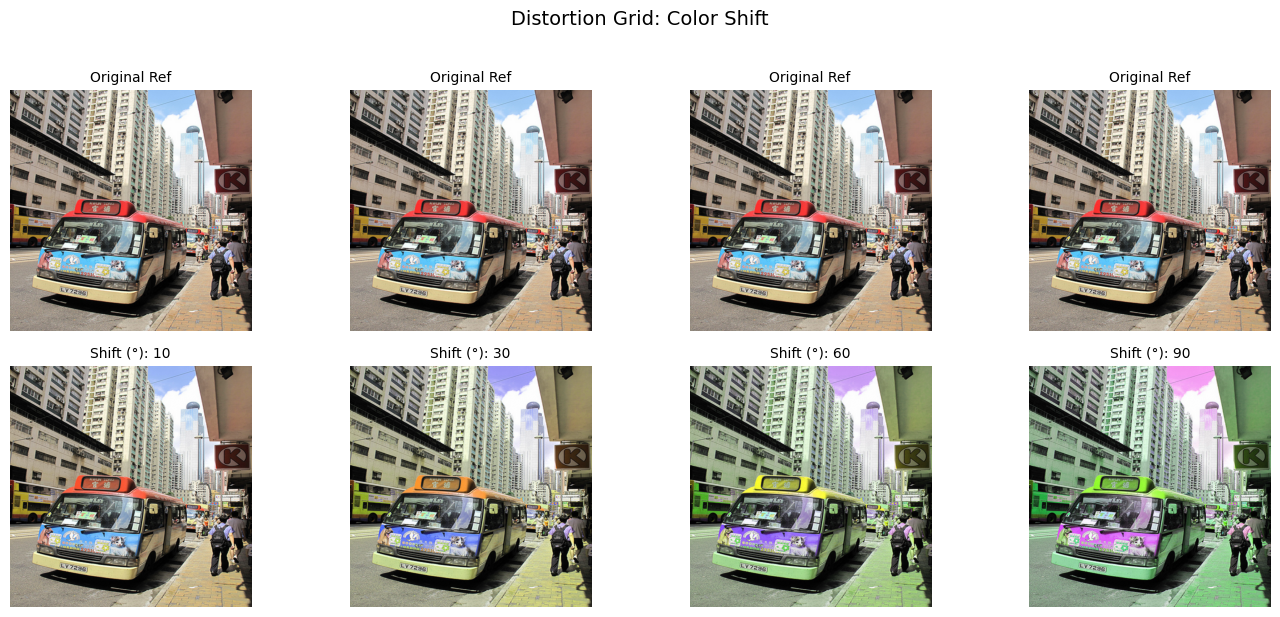

,Shift (°),PSNR (↑),SSIM (↑),LPIPS-Alex (↓),LPIPS-VGG (↓),TPIPS Distance (↓)
0,10,36.00,0.9962,0.0168,0.0179,0.0325
1,30,26.78,0.9773,0.0858,0.1116,0.1725
2,60,22.05,0.9489,0.1597,0.2077,0.3013
3,90,19.43,0.9136,0.2038,0.2543,0.3523


In [165]:
# =========================================================================
# TEST 10: Color Shift (Hue Offset)
# =========================================================================


def apply_color_shift(img_np, shift_deg=0):
    """Shifts color hue in HSV space."""
    img_hsv = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
    img_hsv[:, :, 0] = (
        img_hsv[:, :, 0].astype(int) + int(shift_deg / 2)
    ) % 180
    shifted_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
    return shifted_rgb / 255.0


# Run 2x4 visual grid + metric summary table
df_color_shift = plot_sweep_grid(
    img_ref=img_ref,
    distortion_fn=apply_color_shift,
    levels=[10, 30, 60, 90],
    param_name="Shift (°)",
    exp_title="Color Shift",
)